In [ ]:
import keras
from keras import layers
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize the data
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten the images
x_train = x_train.reshape(-1, 784) # cada imagen de 28x28 se convierte en un vector de 784 elementos
x_test = x_test.reshape(-1, 784)

# Convert labels to one-hot encoding
y_train = keras.utils.to_categorical(y_train, 10) # one hot encoding
y_test = keras.utils.to_categorical(y_test, 10)

11490434/11490434 [==============================] - 1s 0us/step


In [2]:
print(x_train.shape)
print(y_train.shape)
print(y_train[0])

(60000, 784)
(60000, 10)
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 109386 (427.29 KB)
Trainable params: 109386 (427.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/50
750/750 [==============================] - 3s 3ms/step - loss: 0.3077 - accuracy: 0.9116 - val_loss: 0.1557 - val_accuracy: 0.9567
Epoch 2/50
750/750 [==============================] - 2s 3ms/step - loss: 0.1340 - accuracy: 0.9603 - val_loss: 0.1246 - val_accuracy: 0.9

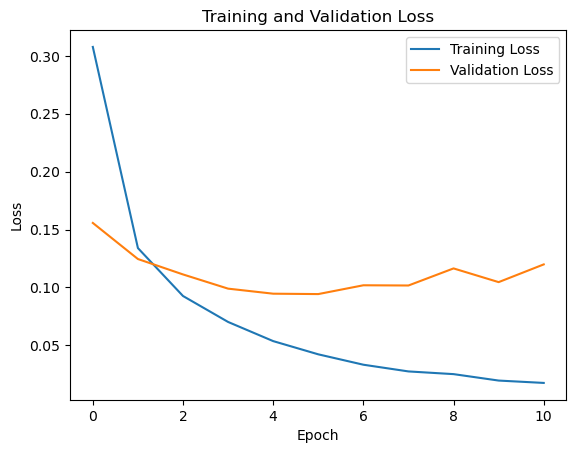

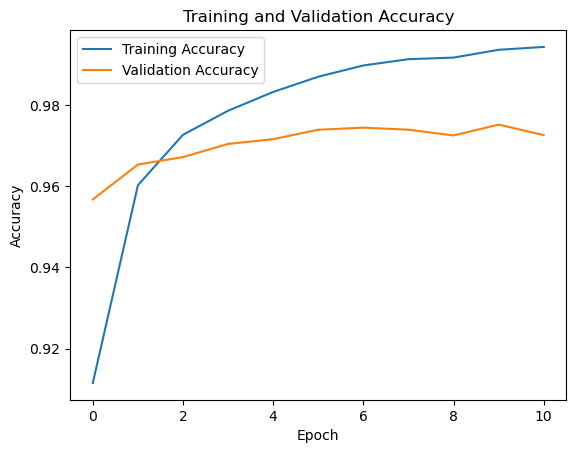

In [ ]:
# Define the model
model = keras.Sequential([
    layers.Input(shape=(784,)),  # Input layer
    layers.Dense(128, activation='relu'),  # Hidden layer with 128 units
    layers.Dense(64, activation='relu'),   # Hidden layer with 64 units
    layers.Dense(10, activation='softmax') # Output layer with 10 units
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print the model summary
model.summary()

# Define early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=5,          # Stop after 5 epochs of no improvement
    restore_best_weights=True  # Restore the best weights
)

# Train the model
history = model.fit(
    x_train, y_train,
    epochs=50,  # Maximum number of epochs
    batch_size=64,
    validation_split=0.2,  # Use 20% of the training data as validation data
    callbacks=[early_stopping]  # Add early stopping callback
)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')

# Plot training & validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Al profesor se le ha parado en la época 12 por que no ha habido mejora en la función de pérdida de validación durante 5 épocas consecutivas, lo que indica que el modelo ha dejado de aprender y podría estar sobreajustándose a los datos de entrenamiento.